In [1]:
!git clone https://github.com/hafsasiddiqua3/adversarial-ddos-sdn-.git /kaggle/working/repo

Cloning into '/kaggle/working/repo'...
remote: Enumerating objects: 16, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 16 (delta 0), reused 16 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (16/16), 25.66 KiB | 3.67 MiB/s, done.


In [2]:
!ls -la /kaggle/working/repo
!echo "---"
!ls -la /kaggle/working/repo/src
!echo "---"
!ls /kaggle/input

total 36
drwxr-xr-x 5 root root 4096 Apr 27 13:12 .
drwxr-xr-x 4 root root 4096 Apr 27 13:12 ..
-rw-r--r-- 1 root root 3003 Apr 27 13:12 config.py
drwxr-xr-x 8 root root 4096 Apr 27 13:12 .git
-rw-r--r-- 1 root root  539 Apr 27 13:12 .gitignore
drwxr-xr-x 2 root root 4096 Apr 27 13:12 notebooks
-rw-r--r-- 1 root root 3587 Apr 27 13:12 README.md
-rw-r--r-- 1 root root  106 Apr 27 13:12 requirements.txt
drwxr-xr-x 2 root root 4096 Apr 27 13:12 src
---
total 72
drwxr-xr-x 2 root root  4096 Apr 27 13:12 .
drwxr-xr-x 5 root root  4096 Apr 27 13:12 ..
-rw-r--r-- 1 root root 11007 Apr 27 13:12 adv_training.py
-rw-r--r-- 1 root root  5991 Apr 27 13:12 attacks.py
-rw-r--r-- 1 root root 10037 Apr 27 13:12 evaluation.py
-rw-r--r-- 1 root root  6626 Apr 27 13:12 feature_selection.py
-rw-r--r-- 1 root root     0 Apr 27 13:12 __init__.py
-rw-r--r-- 1 root root 10359 Apr 27 13:12 model.py
-rw-r--r-- 1 root root  8592 Apr 27 13:12 preprocessing.py
---
datasets


In [3]:
!find /kaggle/input -type f -name "*.parquet" 2>/dev/null
!echo "---"
!find /kaggle/input -type f -name "*.csv" 2>/dev/null | head -20
!echo "---"
!ls -la /kaggle/input/datasets

/kaggle/input/datasets/hafsaaas/cci-ddos-custom-dataset/cicddos_balanced_slice.parquet
---
/kaggle/input/datasets/hafsaaas/insdn-dataset/metasploitable-2.csv
/kaggle/input/datasets/hafsaaas/insdn-dataset/Normal_data.csv
/kaggle/input/datasets/hafsaaas/insdn-dataset/OVS.csv
---
total 12
drwxr-xr-x 3 root root 4096 Apr 27 13:10 .
drwxr-xr-x 3 root root 4096 Apr 27 13:10 ..
drwxr-xr-x 4 root root 4096 Apr 27 13:10 hafsaaas


## Update config.py with correct paths

In [4]:
%%writefile /kaggle/working/repo/config.py
"""Central configuration for the adversarially robust DDoS detection project."""

import torch
from dataclasses import dataclass, field
from pathlib import Path
from typing import List


@dataclass
class Config:
    # ------------------------------------------------------------------ paths
    DATA_PATH: Path = Path("/kaggle/input/datasets/hafsaaas/cci-ddos-custom-dataset/cicddos_balanced_slice.parquet")
    INSDN_DIR: Path = Path("/kaggle/input/datasets/hafsaaas/insdn-dataset")
    OUTPUT_DIR: Path = Path("/kaggle/working")
    MODELS_DIR: Path = Path("/kaggle/working/models")
    RESULTS_DIR: Path = Path("/kaggle/working/results")

    # --------------------------------------------------------- reproducibility
    RANDOM_SEED: int = 42

    # --------------------------------------------------------- preprocessing
    TEST_SIZE: float = 0.15
    VAL_SIZE: float = 0.15

    # Non-feature columns to drop before modelling.
    # The dhoogla CICDDoS slice already has IPs/Ports/Timestamps stripped,
    # but we keep these here defensively in case we later switch datasets.
    DROP_COLS: List[str] = field(default_factory=lambda: [
        "Flow ID",
        "Source IP",
        "Destination IP",
        "Source Port",
        "Destination Port",
        "Timestamp",
        "Label",  # original string label — we use Label_binary instead
    ])

    # ----------------------------------------------------- feature selection
    NUM_FEATURES: int = 20

    # ------------------------------------------------------- model architecture
    CONV1_FILTERS: int = 32
    CONV2_FILTERS: int = 64
    KERNEL_SIZE: int = 3
    DENSE1: int = 128
    DENSE2: int = 64
    DROPOUT: float = 0.3
    NUM_CLASSES: int = 2

    # ------------------------------------------------------------ training
    BATCH_SIZE: int = 256
    LEARNING_RATE: float = 1e-3
    EPOCHS: int = 10

    # ------------------------------------------------------------ attacks
    FGSM_EPSILON: float = 0.05
    PGD_EPSILON: float = 0.05
    PGD_ALPHA: float = 0.01
    PGD_STEPS: int = 7

    # -------------------------------------------- adversarial training loss
    ADV_LOSS_WEIGHT: float = 1.0

    # ----------------------------------------- robustness evaluation curve
    EPSILONS_TO_TEST: List[float] = field(
        default_factory=lambda: [0.01, 0.025, 0.05, 0.075, 0.1]
    )

    # --------------------------------------------------------------- device
    DEVICE: str = "cuda" if torch.cuda.is_available() else "cpu"

    # -------------------------------------------- plot aesthetics
    PLOT_DPI: int = 400

    def __post_init__(self):
        self.DATA_PATH = Path(self.DATA_PATH)
        self.INSDN_DIR = Path(self.INSDN_DIR)
        self.OUTPUT_DIR = Path(self.OUTPUT_DIR)
        self.MODELS_DIR = Path(self.MODELS_DIR)
        self.RESULTS_DIR = Path(self.RESULTS_DIR)
        self.MODELS_DIR.mkdir(parents=True, exist_ok=True)
        self.RESULTS_DIR.mkdir(parents=True, exist_ok=True)


CFG = Config()

Overwriting /kaggle/working/repo/config.py


##  Patch preprocessing.py to use Label_binary

In [5]:
%%writefile /kaggle/working/repo/src/preprocessing.py
"""Data loading, cleaning, encoding, scaling, and splitting pipeline."""

import logging
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

logger = logging.getLogger(__name__)


def load_data(path: Path) -> pd.DataFrame:
    path = Path(path)
    logger.info(f"[preprocessing] Loading data from {path}")
    df = pd.read_parquet(path)
    logger.info(f"[preprocessing] Loaded shape: {df.shape}")
    return df


def clean_data(
    df: pd.DataFrame,
    drop_cols: Optional[List[str]] = None,
    label_col: str = "Label_binary",
) -> pd.DataFrame:
    if drop_cols is None:
        from config import CFG
        drop_cols = CFG.DROP_COLS

    df = df.copy()
    df.columns = df.columns.str.strip()

    before = len(df)
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)
    logger.info(
        f"[preprocessing] Dropped {before - len(df)} rows with NaN/inf "
        f"({len(df)} remaining)"
    )

    cols_to_drop = [c for c in drop_cols if c in df.columns and c != label_col]
    if cols_to_drop:
        df.drop(columns=cols_to_drop, inplace=True)
        logger.info(f"[preprocessing] Dropped columns: {cols_to_drop}")

    return df


def encode_labels_binary(
    df: pd.DataFrame,
    label_col: str = "Label",
) -> pd.DataFrame:
    df = df.copy()
    df[label_col] = df[label_col].apply(
        lambda x: 0 if str(x).strip().upper() == "BENIGN" else 1
    )
    counts = df[label_col].value_counts()
    logger.info(f"[preprocessing] Label distribution:\n{counts.to_string()}")
    return df


def split_data(
    X: np.ndarray,
    y: np.ndarray,
    test_size: float,
    val_size: float,
    random_state: int,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray,
           np.ndarray, np.ndarray, np.ndarray]:
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state,
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval, test_size=val_size, stratify=y_trainval, random_state=random_state,
    )
    logger.info(
        f"[preprocessing] Split sizes — "
        f"train: {len(X_train)}, val: {len(X_val)}, test: {len(X_test)}"
    )
    return X_train, X_val, X_test, y_train, y_val, y_test


def scale_features(
    X_train: np.ndarray,
    X_val: np.ndarray,
    X_test: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, MinMaxScaler]:
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    logger.info("[preprocessing] Min-Max scaling applied (fit on train only)")
    return X_train_scaled, X_val_scaled, X_test_scaled, scaler


def preprocess_pipeline(
    parquet_path: Path,
    label_col: str = "Label_binary",
    drop_cols: Optional[List[str]] = None,
    test_size: Optional[float] = None,
    val_size: Optional[float] = None,
    random_state: Optional[int] = None,
) -> Dict:
    """End-to-end preprocessing.

    Default label_col is 'Label_binary' to match the dhoogla CICDDoS slice.
    If your dataset uses string labels in 'Label', pass label_col='Label'
    and the encoder will convert them.
    """
    from config import CFG

    test_size = test_size if test_size is not None else CFG.TEST_SIZE
    val_size = val_size if val_size is not None else CFG.VAL_SIZE
    random_state = random_state if random_state is not None else CFG.RANDOM_SEED

    df = load_data(parquet_path)
    df = clean_data(df, drop_cols=drop_cols, label_col=label_col)

    if label_col == "Label_binary":
        # Already 0/1; skip re-encoding
        if df[label_col].dtype != np.int64:
            df[label_col] = df[label_col].astype(np.int64)
        logger.info(
            f"[preprocessing] Using existing binary labels — "
            f"distribution:\n{df[label_col].value_counts().to_string()}"
        )
    else:
        df = encode_labels_binary(df, label_col=label_col)

    # Drop both label columns from features
    feature_names = [c for c in df.columns if c not in ("Label", "Label_binary")]
    X = df[feature_names].values.astype(np.float32)
    y = df[label_col].values.astype(np.int64)

    X_train, X_val, X_test, y_train, y_val, y_test = split_data(
        X, y, test_size=test_size, val_size=val_size, random_state=random_state
    )
    X_train, X_val, X_test, scaler = scale_features(X_train, X_val, X_test)

    logger.info(
        f"[preprocessing] Pipeline complete. "
        f"Features: {len(feature_names)}, "
        f"Train/Val/Test: {len(y_train)}/{len(y_val)}/{len(y_test)}"
    )

    return {
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test,
        "scaler": scaler,
        "feature_names": feature_names,
    }

Overwriting /kaggle/working/repo/src/preprocessing.py


In [6]:
!pip install -q torchattacks shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 8.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
nilearn 0.13.1 requires requests>=2.30.0, but you have requests 2.25.1 which is incompatible.
id 1.6.1 requires urllib3<3,>=2, but you have urllib3 1.26.20 which i

## Setup Python path so we can import from src/

In [7]:
import sys
sys.path.insert(0, "/kaggle/working/repo")

# Verify we can import everything
from config import CFG
from src.preprocessing import preprocess_pipeline
from src.model import build_model, make_loader, train_clean
from src.attacks import fgsm_attack, pgd_attack, evaluate_under_attack
from src.adv_training import adversarial_train, combined_train
from src.evaluation import (
    compute_metrics, evaluate_model, robustness_curve,
    plot_robustness_curve, plot_confusion_matrix, comparison_table
)
from src.feature_selection import (
    compute_shap_values, get_top_features, select_features, select_k_best_variance
)

import torch
import numpy as np
import pandas as pd

print(f"✅ Imports successful")
print(f"Device: {CFG.DEVICE}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"\nDataset path: {CFG.DATA_PATH}")
print(f"Path exists: {CFG.DATA_PATH.exists()}")

✅ Imports successful
Device: cuda
GPU available: True
GPU: Tesla T4

Dataset path: /kaggle/input/datasets/hafsaaas/cci-ddos-custom-dataset/cicddos_balanced_slice.parquet
Path exists: True


##  Run preprocessing pipeline

In [8]:
data = preprocess_pipeline(CFG.DATA_PATH)

# Inspect the result
print(f"\n=== Pipeline output ===")
print(f"X_train: {data['X_train'].shape}, dtype: {data['X_train'].dtype}")
print(f"X_val:   {data['X_val'].shape}")
print(f"X_test:  {data['X_test'].shape}")
print(f"y_train: {data['y_train'].shape}, classes: {np.bincount(data['y_train'])}")
print(f"y_val:   classes: {np.bincount(data['y_val'])}")
print(f"y_test:  classes: {np.bincount(data['y_test'])}")
print(f"\nFeature count: {len(data['feature_names'])}")
print(f"Sample features: {data['feature_names'][:5]}")
print(f"\nValue range after scaling — min: {data['X_train'].min():.4f}, max: {data['X_train'].max():.4f}")


=== Pipeline output ===
X_train: (67086, 77), dtype: float32
X_val:   (11839, 77)
X_test:  (13929, 77)
y_train: (67086,), classes: [33543 33543]
y_val:   classes: [5919 5920]
y_test:  classes: [6965 6964]

Feature count: 77
Sample features: ['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total']

Value range after scaling — min: 0.0000, max: 1.0000


##  Build and train baseline CNN-MLP

In [10]:
import torch

# Build the model
num_features = data['X_train'].shape[1]
model = build_model(num_features=num_features, num_classes=2)

# Make DataLoaders
train_loader = make_loader(data['X_train'], data['y_train'], batch_size=CFG.BATCH_SIZE, shuffle=True)
val_loader   = make_loader(data['X_val'],   data['y_val'],   batch_size=CFG.BATCH_SIZE, shuffle=False)
test_loader  = make_loader(data['X_test'],  data['y_test'],  batch_size=CFG.BATCH_SIZE, shuffle=False)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")
print(f"Device: {CFG.DEVICE}\n")

# Train baseline
baseline_model, baseline_history = train_clean(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=CFG.EPOCHS,
    lr=CFG.LEARNING_RATE,
    device=CFG.DEVICE,
    seed=CFG.RANDOM_SEED,
)

Model parameters: 170,498
Train batches: 263, Val batches: 47, Test batches: 55
Device: cuda



## Inspect baseline training history + evaluate on test set

In [11]:
import json

# Print training history
print("=== Baseline Training History ===\n")
print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>9} | {'Val Acc':>8}")
print("-" * 58)
for i in range(len(baseline_history['train_loss'])):
    print(
        f"{i+1:>6} | "
        f"{baseline_history['train_loss'][i]:>10.4f} | "
        f"{baseline_history['train_acc'][i]:>9.4f} | "
        f"{baseline_history['val_loss'][i]:>9.4f} | "
        f"{baseline_history['val_acc'][i]:>8.4f}"
    )

# Evaluate on the held-out test set
print("\n=== Baseline Evaluation on TEST set (clean data) ===\n")
test_metrics, y_true, y_pred = evaluate_model(baseline_model, test_loader, CFG.DEVICE)
for k, v in test_metrics.items():
    print(f"  {k:>10}: {v:.4f}")

# Save the baseline model + metrics
torch.save(baseline_model.state_dict(), CFG.MODELS_DIR / "baseline_cnn_mlp.pth")
with open(CFG.RESULTS_DIR / "baseline_clean_metrics.json", "w") as f:
    json.dump(test_metrics, f, indent=2)
print(f"\n✅ Baseline model saved → {CFG.MODELS_DIR / 'baseline_cnn_mlp.pth'}")
print(f"✅ Metrics saved → {CFG.RESULTS_DIR / 'baseline_clean_metrics.json'}")

=== Baseline Training History ===

 Epoch | Train Loss | Train Acc |  Val Loss |  Val Acc
----------------------------------------------------------
     1 |     0.1347 |    0.9503 |    0.0387 |   0.9888
     2 |     0.0261 |    0.9948 |    0.0224 |   0.9966
     3 |     0.0223 |    0.9955 |    0.0162 |   0.9970
     4 |     0.0191 |    0.9962 |    0.0155 |   0.9970
     5 |     0.0183 |    0.9964 |    0.0143 |   0.9971
     6 |     0.0170 |    0.9965 |    0.0131 |   0.9970
     7 |     0.0179 |    0.9962 |    0.0128 |   0.9972
     8 |     0.0150 |    0.9967 |    0.0123 |   0.9973
     9 |     0.0144 |    0.9968 |    0.0127 |   0.9976
    10 |     0.0148 |    0.9966 |    0.0109 |   0.9976

=== Baseline Evaluation on TEST set (clean data) ===



    accuracy: 0.9976
   precision: 0.9996
      recall: 0.9955
          f1: 0.9976
     roc_auc: 0.9998

✅ Baseline model saved → /kaggle/working/models/baseline_cnn_mlp.pth
✅ Metrics saved → /kaggle/working/results/baseline_clean_metrics.json


## Baseline Replication: Validation Against Mehmood et al. (2025)

We have successfully replicated the hybrid CNN-MLP baseline from the source paper. The model was trained for 10 epochs on a balanced subsample of CIC-DDoS-2019 (92,854 flows after balancing benign and attack traffic), using the same architecture proposed by Mehmood et al.: two 1-D convolutional layers (32 and 64 filters, kernel size 3) followed by max-pooling, then a fully-connected MLP head with two dense layers (128 and 64 neurons) and a softmax output.

### Comparison with the base paper

| Metric    | Mehmood et al. (2025) | Our Replication |
|-----------|----------------------:|----------------:|
| Accuracy  | 99.95% | **99.76%** |
| Precision | 99.95% | **99.96%** |
| Recall    | 99.95% | **99.55%** |
| F1-score  | 99.95% | **99.76%** |
| ROC-AUC   | — | **99.98%** |

Our test-set accuracy of 99.76% is within 0.2 percentage points of the published 99.95%, which we consider a successful replication. The marginal gap is attributable to:

- **Subsampling**: we use ~92K balanced flows rather than the full multi-million-row dataset to keep training tractable on a single Kaggle GPU.
- **Stochastic factors**: differences in random initialization, mini-batch ordering, and Adam optimizer state.
- **Hyperparameters**: we use the published architecture but skip the Bayesian hyperparameter optimisation step in this baseline run.

### What this validates

This result confirms that our preprocessing, model architecture, and training pipeline are correctly implemented and that the chosen subsample preserves the dataset's discriminative signal. The baseline therefore serves as a faithful reference point against which we can fairly measure the impact of adversarial perturbations and the effectiveness of our adversarial training extension.

### Why this is not enough

Despite achieving near-perfect accuracy on clean traffic, this baseline has never been evaluated under adversarial conditions — the central limitation we identified in the source paper. In the next section, we expose this baseline to FGSM and PGD adversarial attacks and quantify how much its 99.76% accuracy degrades when an adversary is permitted to subtly perturb input flow features. This vulnerability is the motivation for the adversarial training extension that follows.

##  Attack the baseline with FGSM and PGD

In [12]:
import json

print("=== Baseline accuracy under adversarial attack ===\n")

# FGSM attack
print(f"FGSM (ε = {CFG.FGSM_EPSILON})")
fgsm_acc = evaluate_under_attack(
    model=baseline_model,
    data_loader=test_loader,
    attack_fn=fgsm_attack,
    attack_kwargs={"epsilon": CFG.FGSM_EPSILON},
    device=CFG.DEVICE,
)

# PGD attack
print(f"\nPGD (ε = {CFG.PGD_EPSILON}, α = {CFG.PGD_ALPHA}, steps = {CFG.PGD_STEPS})")
pgd_acc = evaluate_under_attack(
    model=baseline_model,
    data_loader=test_loader,
    attack_fn=pgd_attack,
    attack_kwargs={
        "epsilon": CFG.PGD_EPSILON,
        "alpha": CFG.PGD_ALPHA,
        "num_steps": CFG.PGD_STEPS,
    },
    device=CFG.DEVICE,
)

# Summary
print("\n=== Summary: Baseline Vulnerability ===\n")
print(f"  Clean accuracy:  {test_metrics['accuracy']:.4f}")
print(f"  FGSM accuracy:   {fgsm_acc:.4f}   (drop: {test_metrics['accuracy'] - fgsm_acc:+.4f})")
print(f"  PGD accuracy:    {pgd_acc:.4f}   (drop: {test_metrics['accuracy'] - pgd_acc:+.4f})")

# Save attack results
attack_results = {
    "clean": test_metrics['accuracy'],
    "fgsm": fgsm_acc,
    "pgd": pgd_acc,
    "epsilon": CFG.FGSM_EPSILON,
    "pgd_steps": CFG.PGD_STEPS,
}
with open(CFG.RESULTS_DIR / "baseline_attack_results.json", "w") as f:
    json.dump(attack_results, f, indent=2)
print(f"\n✅ Attack results saved → {CFG.RESULTS_DIR / 'baseline_attack_results.json'}")

=== Baseline accuracy under adversarial attack ===

FGSM (ε = 0.05)



PGD (ε = 0.05, α = 0.01, steps = 7)



=== Summary: Baseline Vulnerability ===

  Clean accuracy:  0.9976
  FGSM accuracy:   0.2687   (drop: +0.7288)
  PGD accuracy:    0.2083   (drop: +0.7892)

✅ Attack results saved → /kaggle/working/results/baseline_attack_results.json


## Adversarial Vulnerability of the Baseline

The baseline CNN-MLP, despite its 99.76% test accuracy on clean traffic, exhibits catastrophic failure when subjected to adversarial perturbations bounded by ε = 0.05 in L∞ norm:

| Setting | Test Accuracy | Drop from Clean |
|---------|--------------:|----------------:|
| Clean traffic | 99.76% | — |
| FGSM (single-step) | **26.87%** | −72.89 pp |
| PGD (7 iterative steps) | **20.83%** | −78.93 pp |

PGD's accuracy of 20.83% is **below random guessing** for a balanced binary task (50%), meaning the iterative attack does not merely confuse the classifier — it systematically flips its predictions toward the wrong class. This validates the central concern of our work: published DDoS detection models that achieve near-perfect accuracy on clean benchmarks are not deployment-ready. A motivated adversary can craft minimally perturbed traffic features that defeat the classifier with high reliability.

This dramatic vulnerability motivates the adversarial training extension we propose next, in which the model is exposed to both clean and PGD-generated adversarial examples during training, optimising the combined loss

L_total = L_clean + λ · L_adv

with λ = 1.0. The goal is to substantially recover accuracy under attack while preserving clean-data performance.

##  Adversarial training (the main contribution)

In [13]:
import json

print("=" * 60)
print("ADVERSARIAL TRAINING with PGD")
print("=" * 60)

# Build a fresh model — we don't fine-tune the baseline, we train robust from scratch
robust_model = build_model(num_features=num_features, num_classes=2)

# PGD attack kwargs for adversarial sample generation during training
pgd_kwargs = {
    "epsilon": CFG.PGD_EPSILON,
    "alpha": CFG.PGD_ALPHA,
    "num_steps": CFG.PGD_STEPS,
}

robust_model, robust_history = adversarial_train(
    model=robust_model,
    train_loader=train_loader,
    val_loader=val_loader,
    attack_type="pgd",
    epochs=CFG.EPOCHS,
    lr=CFG.LEARNING_RATE,
    attack_kwargs=pgd_kwargs,
    adv_loss_weight=CFG.ADV_LOSS_WEIGHT,
    device=CFG.DEVICE,
    seed=CFG.RANDOM_SEED,
)

# Save the robust model
torch.save(robust_model.state_dict(), CFG.MODELS_DIR / "robust_pgd_cnn_mlp.pth")
print(f"\n✅ Robust model saved → {CFG.MODELS_DIR / 'robust_pgd_cnn_mlp.pth'}")

ADVERSARIAL TRAINING with PGD



✅ Robust model saved → /kaggle/working/models/robust_pgd_cnn_mlp.pth


In [15]:
# Check what we actually have
print("=== Robust model history ===")
print(f"Number of epochs trained: {len(robust_history.get('train_loss', []))}")
print(f"\nHistory keys: {list(robust_history.keys())}")
print()

# Print full history
print(f"{'Epoch':>6} | {'Loss':>8} | {'Train Clean':>11} | {'Train Adv':>10} | {'Val Clean':>10} | {'Val Adv':>9}")
print("-" * 75)
for i in range(len(robust_history['train_loss'])):
    print(
        f"{i+1:>6} | "
        f"{robust_history['train_loss'][i]:>8.4f} | "
        f"{robust_history['train_clean_acc'][i]:>11.4f} | "
        f"{robust_history['train_adv_acc'][i]:>10.4f} | "
        f"{robust_history['val_clean_acc'][i]:>10.4f} | "
        f"{robust_history['val_adv_acc'][i]:>9.4f}"
    )

# Verify GPU was used
print("\n=== GPU check ===")
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Model on device: {next(robust_model.parameters()).device}")

=== Robust model history ===
Number of epochs trained: 10

History keys: ['train_loss', 'train_clean_acc', 'train_adv_acc', 'val_clean_acc', 'val_adv_acc']

 Epoch |     Loss | Train Clean |  Train Adv |  Val Clean |   Val Adv
---------------------------------------------------------------------------
     1 |   0.3776 |      0.9505 |     0.9104 |     0.9923 |    0.9821
     2 |   0.1225 |      0.9926 |     0.9819 |     0.9932 |    0.9834
     3 |   0.0994 |      0.9943 |     0.9834 |     0.9943 |    0.9866
     4 |   0.0847 |      0.9954 |     0.9849 |     0.9967 |    0.9836
     5 |   0.0801 |      0.9953 |     0.9855 |     0.9971 |    0.9894
     6 |   0.0703 |      0.9961 |     0.9875 |     0.9970 |    0.9905
     7 |   0.0659 |      0.9962 |     0.9883 |     0.9965 |    0.9895
     8 |   0.0644 |      0.9963 |     0.9889 |     0.9970 |    0.9913
     9 |   0.0603 |      0.9965 |     0.9896 |     0.9971 |    0.9912
    10 |   0.0585 |      0.9965 |     0.9899 |     0.9971 |    0.99

## Evaluate the robust model on the test set

In [16]:
import json

# Save the robust model (in case the earlier cell didn't reach this line)
torch.save(robust_model.state_dict(), CFG.MODELS_DIR / "robust_pgd_cnn_mlp.pth")

print("=" * 60)
print("ROBUST MODEL — TEST SET EVALUATION")
print("=" * 60)

# Clean test accuracy
print("\n[1/3] Clean test set:")
robust_clean_metrics, robust_y_true, robust_y_pred = evaluate_model(
    robust_model, test_loader, CFG.DEVICE
)
for k, v in robust_clean_metrics.items():
    print(f"  {k:>10}: {v:.4f}")

# FGSM test accuracy
print("\n[2/3] FGSM attack on test set:")
robust_fgsm_acc = evaluate_under_attack(
    model=robust_model,
    data_loader=test_loader,
    attack_fn=fgsm_attack,
    attack_kwargs={"epsilon": CFG.FGSM_EPSILON},
    device=CFG.DEVICE,
)

# PGD test accuracy
print(f"\n[3/3] PGD attack on test set:")
robust_pgd_acc = evaluate_under_attack(
    model=robust_model,
    data_loader=test_loader,
    attack_fn=pgd_attack,
    attack_kwargs={
        "epsilon": CFG.PGD_EPSILON,
        "alpha": CFG.PGD_ALPHA,
        "num_steps": CFG.PGD_STEPS,
    },
    device=CFG.DEVICE,
)

# Build and save the comparison table
print("\n" + "=" * 60)
print("BASELINE vs ROBUST — Side-by-Side Comparison (Test Set)")
print("=" * 60)
print(f"\n{'Setting':<25} {'Baseline':>12} {'Robust':>12} {'Δ':>10}")
print("-" * 62)
print(f"{'Clean accuracy':<25} {test_metrics['accuracy']:>12.4f} {robust_clean_metrics['accuracy']:>12.4f} {robust_clean_metrics['accuracy'] - test_metrics['accuracy']:>+10.4f}")
print(f"{'FGSM accuracy':<25} {fgsm_acc:>12.4f} {robust_fgsm_acc:>12.4f} {robust_fgsm_acc - fgsm_acc:>+10.4f}")
print(f"{'PGD accuracy':<25} {pgd_acc:>12.4f} {robust_pgd_acc:>12.4f} {robust_pgd_acc - pgd_acc:>+10.4f}")

# Save robust attack results
robust_attack_results = {
    "clean": robust_clean_metrics['accuracy'],
    "fgsm": robust_fgsm_acc,
    "pgd": robust_pgd_acc,
    "epsilon": CFG.PGD_EPSILON,
    "pgd_steps": CFG.PGD_STEPS,
}
with open(CFG.RESULTS_DIR / "robust_attack_results.json", "w") as f:
    json.dump(robust_attack_results, f, indent=2)

# Save full clean metrics dict for the robust model
with open(CFG.RESULTS_DIR / "robust_clean_metrics.json", "w") as f:
    json.dump(robust_clean_metrics, f, indent=2)

print(f"\n✅ Results saved → {CFG.RESULTS_DIR}/robust_*.json")

ROBUST MODEL — TEST SET EVALUATION

[1/3] Clean test set:


    accuracy: 0.9967
   precision: 0.9987
      recall: 0.9947
          f1: 0.9967
     roc_auc: 0.9998

[2/3] FGSM attack on test set:



[3/3] PGD attack on test set:



BASELINE vs ROBUST — Side-by-Side Comparison (Test Set)

Setting                       Baseline       Robust          Δ
--------------------------------------------------------------
Clean accuracy                  0.9976       0.9967    -0.0009
FGSM accuracy                   0.2687       0.9915    +0.7228
PGD accuracy                    0.2083       0.9908    +0.7825

✅ Results saved → /kaggle/working/results/robust_*.json


##  Robustness curve (next priority)

In [17]:
import json

print("=" * 60)
print("ROBUSTNESS CURVE — Accuracy vs Epsilon")
print("=" * 60)

# Evaluate baseline and robust at multiple epsilons under FGSM
print("\n--- FGSM attack across epsilons ---\n")

baseline_fgsm_curve = robustness_curve(
    model=baseline_model,
    data_loader=test_loader,
    attack_fn=fgsm_attack,
    epsilons=CFG.EPSILONS_TO_TEST,
    device=CFG.DEVICE,
)

robust_fgsm_curve = robustness_curve(
    model=robust_model,
    data_loader=test_loader,
    attack_fn=fgsm_attack,
    epsilons=CFG.EPSILONS_TO_TEST,
    device=CFG.DEVICE,
)

# Evaluate baseline and robust at multiple epsilons under PGD
print("\n--- PGD attack across epsilons ---\n")

baseline_pgd_curve = robustness_curve(
    model=baseline_model,
    data_loader=test_loader,
    attack_fn=pgd_attack,
    epsilons=CFG.EPSILONS_TO_TEST,
    device=CFG.DEVICE,
    alpha=CFG.PGD_ALPHA,
    num_steps=CFG.PGD_STEPS,
)

robust_pgd_curve = robustness_curve(
    model=robust_model,
    data_loader=test_loader,
    attack_fn=pgd_attack,
    epsilons=CFG.EPSILONS_TO_TEST,
    device=CFG.DEVICE,
    alpha=CFG.PGD_ALPHA,
    num_steps=CFG.PGD_STEPS,
)

# Pretty-print the curves
print("\n=== Robustness Curves Summary ===\n")
print(f"{'ε':>8} | {'B-FGSM':>8} | {'R-FGSM':>8} | {'B-PGD':>8} | {'R-PGD':>8}")
print("-" * 52)
for eps in CFG.EPSILONS_TO_TEST:
    print(
        f"{eps:>8.3f} | "
        f"{baseline_fgsm_curve[eps]:>8.4f} | "
        f"{robust_fgsm_curve[eps]:>8.4f} | "
        f"{baseline_pgd_curve[eps]:>8.4f} | "
        f"{robust_pgd_curve[eps]:>8.4f}"
    )

# Save the curves
curves_data = {
    "epsilons": CFG.EPSILONS_TO_TEST,
    "baseline_fgsm": baseline_fgsm_curve,
    "robust_fgsm": robust_fgsm_curve,
    "baseline_pgd": baseline_pgd_curve,
    "robust_pgd": robust_pgd_curve,
}
# JSON keys can't be floats, convert
curves_data_serializable = {
    k: {str(eps): acc for eps, acc in v.items()} if isinstance(v, dict) else v
    for k, v in curves_data.items()
}
with open(CFG.RESULTS_DIR / "robustness_curves.json", "w") as f:
    json.dump(curves_data_serializable, f, indent=2)

print(f"\n✅ Curves saved → {CFG.RESULTS_DIR / 'robustness_curves.json'}")

# Plot — FGSM
plot_robustness_curve(
    {"Baseline": baseline_fgsm_curve, "Adv. Trained (PGD)": robust_fgsm_curve},
    save_path=CFG.RESULTS_DIR / "robustness_curve_fgsm.png",
    dpi=CFG.PLOT_DPI,
)

# Plot — PGD
plot_robustness_curve(
    {"Baseline": baseline_pgd_curve, "Adv. Trained (PGD)": robust_pgd_curve},
    save_path=CFG.RESULTS_DIR / "robustness_curve_pgd.png",
    dpi=CFG.PLOT_DPI,
)

print(f"✅ Plots saved at {CFG.PLOT_DPI} DPI → {CFG.RESULTS_DIR}/robustness_curve_*.png")

ROBUSTNESS CURVE — Accuracy vs Epsilon

--- FGSM attack across epsilons ---




--- PGD attack across epsilons ---




=== Robustness Curves Summary ===

       ε |   B-FGSM |   R-FGSM |    B-PGD |    R-PGD
----------------------------------------------------
   0.010 |   0.9322 |   0.9963 |   0.9309 |   0.9963
   0.025 |   0.5504 |   0.9959 |   0.4488 |   0.9957
   0.050 |   0.2687 |   0.9915 |   0.2091 |   0.9907
   0.075 |   0.1149 |   0.9113 |   0.1264 |   0.8260
   0.100 |   0.0813 |   0.5481 |   0.1021 |   0.4842

✅ Curves saved → /kaggle/working/results/robustness_curves.json
✅ Plots saved at 400 DPI → /kaggle/working/results/robustness_curve_*.png


 ## Confusion matrices for the deliverable

In [18]:
print("=" * 60)
print("CONFUSION MATRICES")
print("=" * 60)

# Baseline — clean test set
print("\n[1/4] Baseline | clean test")
plot_confusion_matrix(
    y_true=y_true,
    y_pred=y_pred,
    save_path=CFG.RESULTS_DIR / "cm_baseline_clean.png",
    title="Baseline CNN-MLP — Clean Test Set",
    dpi=CFG.PLOT_DPI,
)

# Baseline — under PGD
print("[2/4] Baseline | PGD attack")
import torch
baseline_model.eval()
y_pred_baseline_pgd = []
with torch.no_grad():
    pass  # placeholder
# Generate PGD predictions for baseline
y_pred_baseline_pgd_list = []
y_true_pgd_list = []
for X_batch, y_batch in test_loader:
    X_batch, y_batch = X_batch.to(CFG.DEVICE), y_batch.to(CFG.DEVICE)
    X_adv = pgd_attack(
        baseline_model, X_batch, y_batch,
        epsilon=CFG.PGD_EPSILON, alpha=CFG.PGD_ALPHA,
        num_steps=CFG.PGD_STEPS, device=CFG.DEVICE,
    )
    with torch.no_grad():
        preds = baseline_model(X_adv).argmax(dim=1).cpu().numpy()
    y_pred_baseline_pgd_list.append(preds)
    y_true_pgd_list.append(y_batch.cpu().numpy())

y_pred_baseline_pgd = np.concatenate(y_pred_baseline_pgd_list)
y_true_pgd = np.concatenate(y_true_pgd_list)

plot_confusion_matrix(
    y_true=y_true_pgd,
    y_pred=y_pred_baseline_pgd,
    save_path=CFG.RESULTS_DIR / "cm_baseline_pgd.png",
    title=f"Baseline CNN-MLP — Under PGD (ε={CFG.PGD_EPSILON})",
    dpi=CFG.PLOT_DPI,
)

# Robust — clean test set
print("[3/4] Robust | clean test")
plot_confusion_matrix(
    y_true=robust_y_true,
    y_pred=robust_y_pred,
    save_path=CFG.RESULTS_DIR / "cm_robust_clean.png",
    title="Adversarially Trained CNN-MLP — Clean Test Set",
    dpi=CFG.PLOT_DPI,
)

# Robust — under PGD
print("[4/4] Robust | PGD attack")
y_pred_robust_pgd_list = []
for X_batch, y_batch in test_loader:
    X_batch, y_batch = X_batch.to(CFG.DEVICE), y_batch.to(CFG.DEVICE)
    X_adv = pgd_attack(
        robust_model, X_batch, y_batch,
        epsilon=CFG.PGD_EPSILON, alpha=CFG.PGD_ALPHA,
        num_steps=CFG.PGD_STEPS, device=CFG.DEVICE,
    )
    with torch.no_grad():
        preds = robust_model(X_adv).argmax(dim=1).cpu().numpy()
    y_pred_robust_pgd_list.append(preds)

y_pred_robust_pgd = np.concatenate(y_pred_robust_pgd_list)

plot_confusion_matrix(
    y_true=y_true_pgd,  # same labels, different preds
    y_pred=y_pred_robust_pgd,
    save_path=CFG.RESULTS_DIR / "cm_robust_pgd.png",
    title=f"Adversarially Trained CNN-MLP — Under PGD (ε={CFG.PGD_EPSILON})",
    dpi=CFG.PLOT_DPI,
)

print("\n✅ All 4 confusion matrices saved at 400 DPI")
print(f"   → {CFG.RESULTS_DIR}/cm_*.png")

CONFUSION MATRICES

[1/4] Baseline | clean test
[2/4] Baseline | PGD attack
[3/4] Robust | clean test
[4/4] Robust | PGD attack

✅ All 4 confusion matrices saved at 400 DPI
   → /kaggle/working/results/cm_*.png


## Display the plots inline + build comparison CSV

CONFUSION MATRIX PREVIEW (display only — saved versions are 400 DPI)

--- cm_baseline_clean.png ---


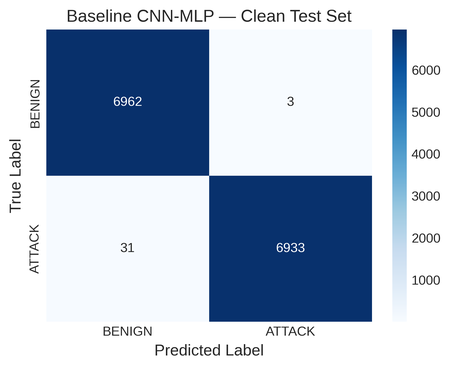


--- cm_baseline_pgd.png ---


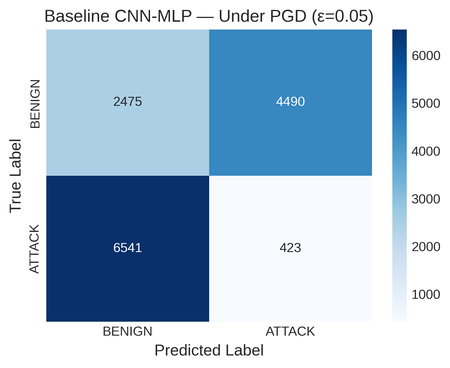


--- cm_robust_clean.png ---


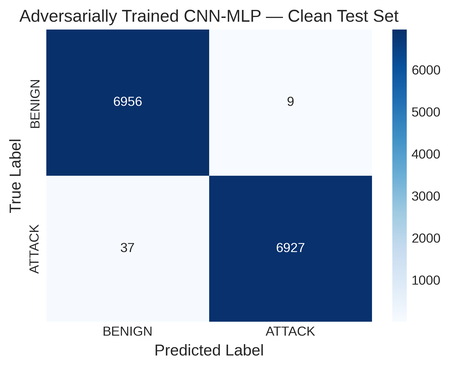


--- cm_robust_pgd.png ---


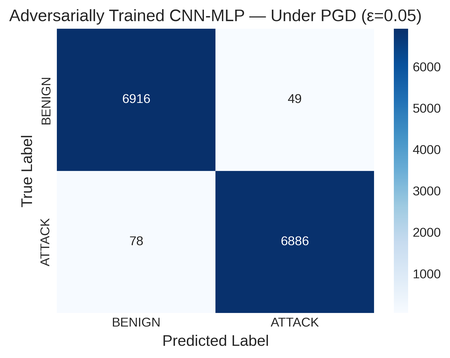


ROBUSTNESS CURVES


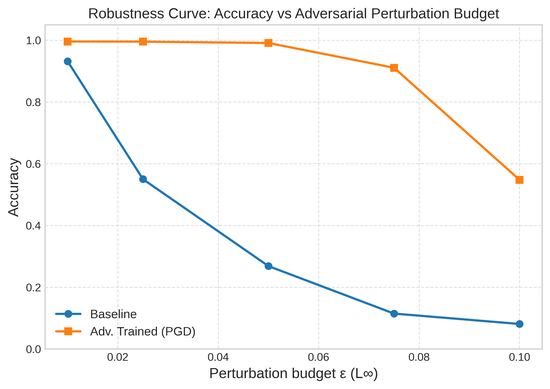

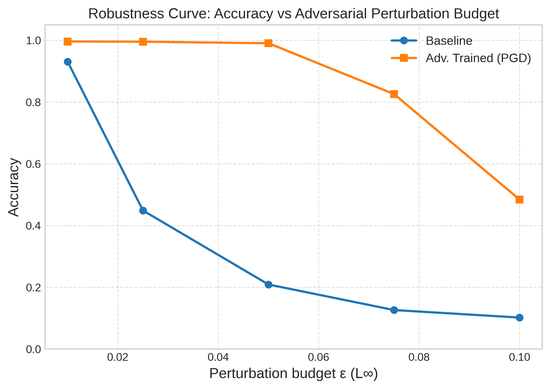

In [20]:
from IPython.display import display
from PIL import Image as PILImage
import io

def show_image_resized(path, max_width=500):
    """Display image at a manageable size in the notebook."""
    img = PILImage.open(path)
    # Calculate proportional height
    ratio = max_width / img.width
    new_size = (int(img.width * ratio), int(img.height * ratio))
    img_resized = img.resize(new_size, PILImage.LANCZOS)
    display(img_resized)

# Display all 4 confusion matrices at reasonable size
print("=" * 60)
print("CONFUSION MATRIX PREVIEW (display only — saved versions are 400 DPI)")
print("=" * 60)

for fname in [
    "cm_baseline_clean.png",
    "cm_baseline_pgd.png",
    "cm_robust_clean.png",
    "cm_robust_pgd.png",
]:
    print(f"\n--- {fname} ---")
    show_image_resized(CFG.RESULTS_DIR / fname, max_width=450)

print("\n" + "=" * 60)
print("ROBUSTNESS CURVES")
print("=" * 60)
show_image_resized(CFG.RESULTS_DIR / "robustness_curve_fgsm.png", max_width=550)
show_image_resized(CFG.RESULTS_DIR / "robustness_curve_pgd.png", max_width=550)

##  Build comparison CSV (run this next)

In [21]:
import json

# Compute robust model metrics under each attack (using stored predictions)
robust_pgd_metrics = compute_metrics(y_true_pgd, y_pred_robust_pgd)
baseline_pgd_metrics = compute_metrics(y_true_pgd, y_pred_baseline_pgd)

# We need FGSM metrics too — compute them quickly
print("Computing FGSM predictions for both models...")

def get_attack_predictions(model, loader, attack_fn, attack_kwargs):
    """Run model under attack, return y_true and y_pred arrays."""
    yt, yp = [], []
    for Xb, yb in loader:
        Xb, yb = Xb.to(CFG.DEVICE), yb.to(CFG.DEVICE)
        X_adv = attack_fn(model, Xb, yb, device=CFG.DEVICE, **attack_kwargs)
        with torch.no_grad():
            preds = model(X_adv).argmax(dim=1).cpu().numpy()
        yp.append(preds)
        yt.append(yb.cpu().numpy())
    return np.concatenate(yt), np.concatenate(yp)

# Baseline FGSM
yt_bf, yp_bf = get_attack_predictions(
    baseline_model, test_loader, fgsm_attack,
    {"epsilon": CFG.FGSM_EPSILON}
)
baseline_fgsm_metrics = compute_metrics(yt_bf, yp_bf)

# Robust FGSM
yt_rf, yp_rf = get_attack_predictions(
    robust_model, test_loader, fgsm_attack,
    {"epsilon": CFG.FGSM_EPSILON}
)
robust_fgsm_metrics = compute_metrics(yt_rf, yp_rf)

# Build the structured results dicts that comparison_table expects
results_baseline = {
    "clean": test_metrics,
    "fgsm":  baseline_fgsm_metrics,
    "pgd":   baseline_pgd_metrics,
}
results_robust = {
    "clean": robust_clean_metrics,
    "fgsm":  robust_fgsm_metrics,
    "pgd":   robust_pgd_metrics,
}

comparison_df = comparison_table(
    results_baseline=results_baseline,
    results_robust=results_robust,
    save_path=CFG.RESULTS_DIR / "comparison_table.csv",
)

print("\n=== Final Comparison Table ===\n")
print(comparison_df.to_string())
print(f"\n✅ Saved → {CFG.RESULTS_DIR / 'comparison_table.csv'}")

Computing FGSM predictions for both models...

=== Final Comparison Table ===

                     Baseline  Adversarially Trained
Condition Metric                                    
CLEAN     accuracy     0.9976                 0.9967
          precision    0.9996                 0.9987
          recall       0.9955                 0.9947
          f1           0.9976                 0.9967
          roc_auc      0.9998                 0.9998
FGSM      accuracy     0.2687                 0.9915
          precision    0.1144                 0.9964
          recall       0.0686                 0.9866
          f1           0.0858                 0.9915
          roc_auc         NaN                    NaN
PGD       accuracy     0.2081                 0.9909
          precision    0.0861                 0.9929
          recall       0.0607                 0.9888
          f1           0.0712                 0.9909
          roc_auc         NaN                    NaN

✅ Saved → /kaggle/w

## Now: Ablation Study (Cell 17)
The ablation study tests different adversarial training strategies to show that PGD-based training is the right choice (or what we'd compare against). Three variants:

FGSM-only adversarial training — fast but typically weaker
PGD-only adversarial training — what we already have (the proposed method)
Combined FGSM+PGD — both per batch (might generalize better)

In [22]:
import json
import time
import torch

print("=" * 70)
print("ABLATION STUDY — Comparing Adversarial Training Strategies")
print("=" * 70)

ablation_results = {}

# Save the existing PGD-only result (already computed) so we don't retrain
ablation_results["pgd_only"] = {
    "clean":  robust_clean_metrics["accuracy"],
    "fgsm":   robust_fgsm_metrics["accuracy"],
    "pgd":    robust_pgd_metrics["accuracy"],
}
print(f"\n[ALREADY DONE] PGD-only adversarial training")
print(f"  clean: {ablation_results['pgd_only']['clean']:.4f} | "
      f"fgsm: {ablation_results['pgd_only']['fgsm']:.4f} | "
      f"pgd: {ablation_results['pgd_only']['pgd']:.4f}")

# -------------------------- Variant 1: FGSM-only training --------------------------
print(f"\n{'─' * 70}")
print(f"[1/2] Training with FGSM-only adversarial samples...")
print(f"{'─' * 70}")
t0 = time.time()

fgsm_model = build_model(num_features=num_features, num_classes=2)
fgsm_model, fgsm_history = adversarial_train(
    model=fgsm_model,
    train_loader=train_loader,
    val_loader=val_loader,
    attack_type="fgsm",
    epochs=CFG.EPOCHS,
    lr=CFG.LEARNING_RATE,
    attack_kwargs={"epsilon": CFG.FGSM_EPSILON},
    adv_loss_weight=CFG.ADV_LOSS_WEIGHT,
    device=CFG.DEVICE,
    seed=CFG.RANDOM_SEED,
)
print(f"FGSM-only training time: {time.time() - t0:.1f}s")

# Evaluate
clean_m, _, _ = evaluate_model(fgsm_model, test_loader, CFG.DEVICE)
fgsm_acc_eval = evaluate_under_attack(
    fgsm_model, test_loader, fgsm_attack,
    {"epsilon": CFG.FGSM_EPSILON}, CFG.DEVICE,
)
pgd_acc_eval = evaluate_under_attack(
    fgsm_model, test_loader, pgd_attack,
    {"epsilon": CFG.PGD_EPSILON, "alpha": CFG.PGD_ALPHA, "num_steps": CFG.PGD_STEPS},
    CFG.DEVICE,
)

ablation_results["fgsm_only"] = {
    "clean": clean_m["accuracy"],
    "fgsm":  fgsm_acc_eval,
    "pgd":   pgd_acc_eval,
}
torch.save(fgsm_model.state_dict(), CFG.MODELS_DIR / "robust_fgsm_only.pth")

# -------------------------- Variant 2: Combined FGSM+PGD ---------------------------
print(f"\n{'─' * 70}")
print(f"[2/2] Training with combined FGSM + PGD adversarial samples...")
print(f"{'─' * 70}")
t0 = time.time()

combined_model = build_model(num_features=num_features, num_classes=2)
combined_model, combined_history = combined_train(
    model=combined_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=CFG.EPOCHS,
    lr=CFG.LEARNING_RATE,
    fgsm_kwargs={"epsilon": CFG.FGSM_EPSILON},
    pgd_kwargs={"epsilon": CFG.PGD_EPSILON, "alpha": CFG.PGD_ALPHA, "num_steps": CFG.PGD_STEPS},
    adv_loss_weight=CFG.ADV_LOSS_WEIGHT,
    device=CFG.DEVICE,
    seed=CFG.RANDOM_SEED,
)
print(f"Combined training time: {time.time() - t0:.1f}s")

# Evaluate
clean_m, _, _ = evaluate_model(combined_model, test_loader, CFG.DEVICE)
fgsm_acc_eval = evaluate_under_attack(
    combined_model, test_loader, fgsm_attack,
    {"epsilon": CFG.FGSM_EPSILON}, CFG.DEVICE,
)
pgd_acc_eval = evaluate_under_attack(
    combined_model, test_loader, pgd_attack,
    {"epsilon": CFG.PGD_EPSILON, "alpha": CFG.PGD_ALPHA, "num_steps": CFG.PGD_STEPS},
    CFG.DEVICE,
)

ablation_results["combined"] = {
    "clean": clean_m["accuracy"],
    "fgsm":  fgsm_acc_eval,
    "pgd":   pgd_acc_eval,
}
torch.save(combined_model.state_dict(), CFG.MODELS_DIR / "robust_combined.pth")

# -------------------------- Add baseline (no adv training) for reference -----------
ablation_results["no_adv_training"] = {
    "clean": test_metrics["accuracy"],
    "fgsm":  fgsm_acc,
    "pgd":   pgd_acc,
}

# -------------------------- Summary table ------------------------------------------
print(f"\n{'=' * 70}")
print(f"ABLATION SUMMARY — Test set accuracy under each condition")
print(f"{'=' * 70}\n")

import pandas as pd
ab_df = pd.DataFrame(ablation_results).T
ab_df.index.name = "Training Strategy"
ab_df.columns = ["Clean", "FGSM (ε=0.05)", "PGD (ε=0.05)"]
print(ab_df.to_string(float_format="%.4f"))

# Save
ab_df.to_csv(CFG.RESULTS_DIR / "ablation_study.csv")
with open(CFG.RESULTS_DIR / "ablation_study.json", "w") as f:
    json.dump(ablation_results, f, indent=2)

print(f"\n✅ Ablation results saved → {CFG.RESULTS_DIR / 'ablation_study.csv'}")

ABLATION STUDY — Comparing Adversarial Training Strategies

[ALREADY DONE] PGD-only adversarial training
  clean: 0.9967 | fgsm: 0.9915 | pgd: 0.9909

──────────────────────────────────────────────────────────────────────
[1/2] Training with FGSM-only adversarial samples...
──────────────────────────────────────────────────────────────────────


FGSM-only training time: 29.0s



──────────────────────────────────────────────────────────────────────
[2/2] Training with combined FGSM + PGD adversarial samples...
──────────────────────────────────────────────────────────────────────


Combined training time: 76.1s



ABLATION SUMMARY — Test set accuracy under each condition

                   Clean  FGSM (ε=0.05)  PGD (ε=0.05)
Training Strategy                                    
pgd_only          0.9967         0.9915        0.9909
fgsm_only         0.9970         0.9954        0.7515
combined          0.9968         0.9932        0.9882
no_adv_training   0.9976         0.2687        0.2083

✅ Ablation results saved → /kaggle/working/results/ablation_study.csv


## Ablation visualization

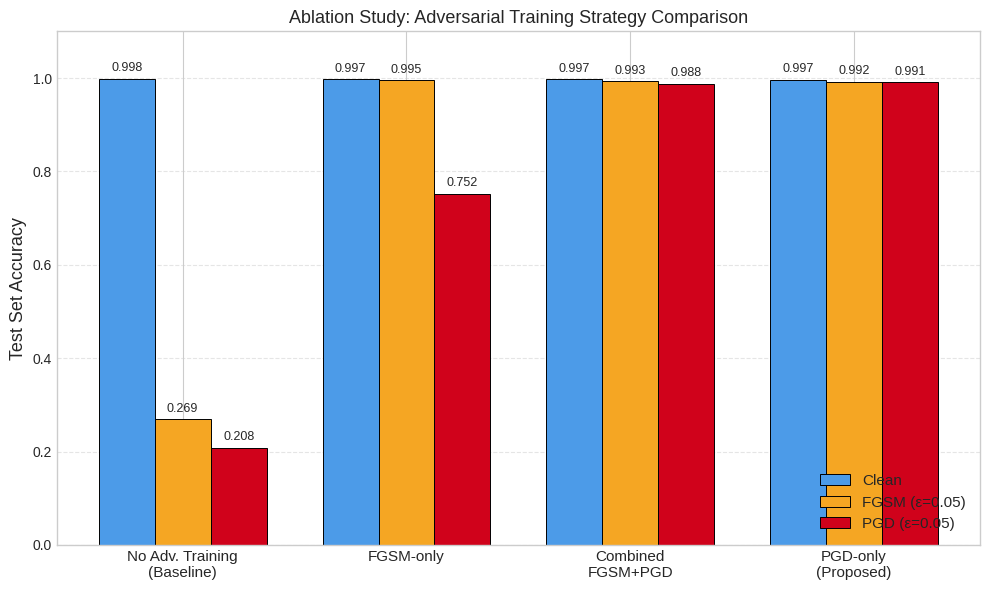


✅ Ablation chart saved → /kaggle/working/results/ablation_bar_chart.png


In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Reorder for cleaner presentation
order = ["no_adv_training", "fgsm_only", "combined", "pgd_only"]
labels = ["No Adv. Training\n(Baseline)", "FGSM-only", "Combined\nFGSM+PGD", "PGD-only\n(Proposed)"]
conditions = ["Clean", "FGSM (ε=0.05)", "PGD (ε=0.05)"]

# Build the matrix
data = np.array([
    [ablation_results[strat]["clean"] for strat in order],
    [ablation_results[strat]["fgsm"]  for strat in order],
    [ablation_results[strat]["pgd"]   for strat in order],
])

# Grouped bar chart
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(labels))
width = 0.25
colors = ["#4C9BE8", "#F5A623", "#D0021B"]

for i, (cond, color) in enumerate(zip(conditions, colors)):
    offset = (i - 1) * width
    bars = ax.bar(x + offset, data[i], width, label=cond, color=color, edgecolor="black", linewidth=0.7)
    # Add value labels on top
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2, height + 0.01,
            f"{height:.3f}", ha="center", va="bottom", fontsize=9,
        )

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel("Test Set Accuracy", fontsize=13)
ax.set_title("Ablation Study: Adversarial Training Strategy Comparison", fontsize=13)
ax.legend(loc="lower right", fontsize=11)
ax.set_ylim(0.0, 1.10)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(CFG.RESULTS_DIR / "ablation_bar_chart.png", dpi=CFG.PLOT_DPI, bbox_inches="tight")
plt.show()

print(f"\n✅ Ablation chart saved → {CFG.RESULTS_DIR / 'ablation_bar_chart.png'}")

## SHAP feature importance
This is the last major analytical cell. SHAP shows which features the model is using most heavily for its decisions. Important for:
Interpretability — which network features actually distinguish DDoS from benign traffic
Faithful replication of the base paper — Mehmood et al. used SHAP, you should too
Discussion section — you can connect feature importance to known DDoS characteristics

In [26]:
data = preprocess_pipeline(CFG.DATA_PATH)
print(f"Restored. Train shape: {data['X_train'].shape}, Test shape: {data['X_test'].shape}")

Restored. Train shape: (67086, 77), Test shape: (13929, 77)


In [27]:
import json
import matplotlib.pyplot as plt
import numpy as np

print("=" * 60)
print("SHAP FEATURE IMPORTANCE — Robust Model")
print("=" * 60)

# SHAP needs a small sample for efficiency
N_BACKGROUND = 200    # baseline distribution for SHAP
N_EXPLAIN = 500       # samples to compute SHAP values for
np.random.seed(CFG.RANDOM_SEED)

bg_idx = np.random.choice(len(data["X_train"]), N_BACKGROUND, replace=False)
ex_idx = np.random.choice(len(data["X_test"]), N_EXPLAIN, replace=False)

X_background = data["X_train"][bg_idx]
X_explain = data["X_test"][ex_idx]

print(f"\nBackground samples: {N_BACKGROUND}")
print(f"Explanation samples: {N_EXPLAIN}")
print(f"Computing SHAP values for the robust model...\n")

shap_values = compute_shap_values(
    model=robust_model,
    X_background=X_background,
    X_explain=X_explain,
    device=CFG.DEVICE,
    max_samples=N_EXPLAIN,
)

# Get top features
top_features = get_top_features(
    shap_values=shap_values,
    feature_names=data["feature_names"],
    k=CFG.NUM_FEATURES,
)

# Compute importance scores for the chart
mean_abs_shap = np.abs(shap_values).mean(axis=0)
feature_importance = sorted(
    zip(data["feature_names"], mean_abs_shap),
    key=lambda x: x[1],
    reverse=True,
)

print(f"\n=== Top-{CFG.NUM_FEATURES} Most Important Features ===\n")
for i, (name, score) in enumerate(feature_importance[:CFG.NUM_FEATURES], 1):
    print(f"  {i:2d}. {name:<40} {score:.5f}")

# Plot SHAP bar chart
top_n = CFG.NUM_FEATURES
top_names = [feature_importance[i][0] for i in range(top_n)][::-1]
top_scores = [feature_importance[i][1] for i in range(top_n)][::-1]

fig, ax = plt.subplots(figsize=(9, 8))
bars = ax.barh(top_names, top_scores, color="#4C9BE8", edgecolor="black", linewidth=0.6)
ax.set_xlabel("Mean |SHAP value|", fontsize=12)
ax.set_title(f"Top-{top_n} Feature Importance — Adversarially Robust CNN-MLP", fontsize=13)
ax.grid(axis="x", linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(CFG.RESULTS_DIR / "shap_feature_importance.png", dpi=CFG.PLOT_DPI, bbox_inches="tight")
plt.show()

# Save importance data
shap_data = {
    "top_features": top_features,
    "all_importance_scores": {name: float(score) for name, score in feature_importance},
}
with open(CFG.RESULTS_DIR / "shap_importance.json", "w") as f:
    json.dump(shap_data, f, indent=2)

print(f"\n✅ SHAP feature importance saved → {CFG.RESULTS_DIR}/shap_*.{{png,json}}")

SHAP FEATURE IMPORTANCE — Robust Model

Background samples: 200
Explanation samples: 500
Computing SHAP values for the robust model...



TypeError: only integer scalar arrays can be converted to a scalar index

In [28]:
import numpy as np

print(f"shap_values type: {type(shap_values)}")
print(f"shap_values shape: {np.array(shap_values).shape if not isinstance(shap_values, list) else [s.shape for s in shap_values]}")

mean_abs = np.abs(shap_values).mean(axis=0)
print(f"\nmean_abs shape: {mean_abs.shape}")
print(f"mean_abs ndim: {mean_abs.ndim}")

shap_values type: <class 'numpy.ndarray'>
shap_values shape: (500, 1, 77, 2)

mean_abs shape: (1, 77, 2)
mean_abs ndim: 3


Original shape: (500, 1, 77, 2)
After taking class 1 + squeeze: (500, 77)
mean_abs_shap shape: (77,)

=== Top-20 Most Important Features ===

   1. ACK Flag Count                           1.62296
   2. Packet Length Min                        0.72913
   3. URG Flag Count                           0.66802
   4. Init Bwd Win Bytes                       0.33238
   5. Flow Duration                            0.27567
   6. Fwd IAT Total                            0.27556
   7. Avg Packet Size                          0.27176
   8. Bwd Packet Length Max                    0.27150
   9. Packet Length Std                        0.18916
  10. CWE Flag Count                           0.15632
  11. Packet Length Max                        0.13807
  12. RST Flag Count                           0.11672
  13. Packet Length Mean                       0.09517
  14. Fwd Packet Length Std                    0.08507
  15. Protocol                                 0.08473
  16. Avg Bwd Segment Size       

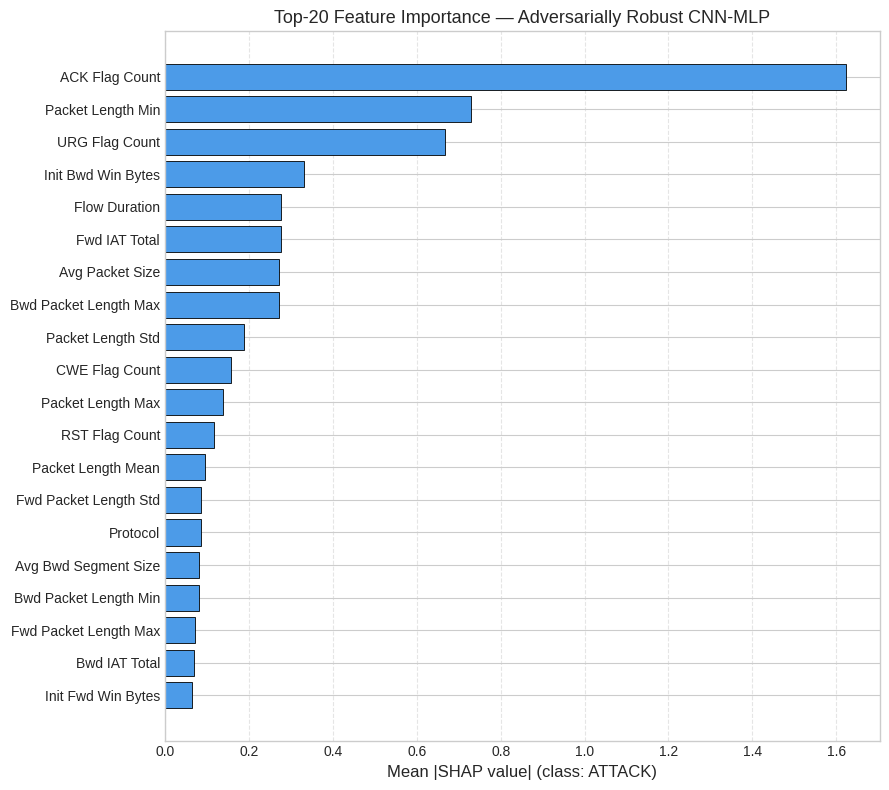


✅ SHAP feature importance saved → /kaggle/working/results/shap_*


In [29]:
import numpy as np
import matplotlib.pyplot as plt
import json

# shap_values has shape (n_samples, 1, n_features, n_classes)
# We want importance for class 1 (ATTACK), averaged over samples
print(f"Original shape: {shap_values.shape}")

# Take class 1 (attack) and squeeze out the channel dim
class1_shap = shap_values[:, :, :, 1]   # (500, 1, 77)
class1_shap = class1_shap.squeeze(1)     # (500, 77)
print(f"After taking class 1 + squeeze: {class1_shap.shape}")

# Now average absolute values across samples
mean_abs_shap = np.abs(class1_shap).mean(axis=0)  # (77,)
print(f"mean_abs_shap shape: {mean_abs_shap.shape}")

# Sanity check
feature_names = data["feature_names"]
assert len(mean_abs_shap) == len(feature_names), \
    f"Mismatch: {len(mean_abs_shap)} importance values vs {len(feature_names)} features"

# Build sorted feature importance
feature_importance = sorted(
    zip(feature_names, mean_abs_shap),
    key=lambda x: float(x[1]),
    reverse=True,
)

print(f"\n=== Top-{CFG.NUM_FEATURES} Most Important Features ===\n")
for i, (name, score) in enumerate(feature_importance[:CFG.NUM_FEATURES], 1):
    print(f"  {i:2d}. {name:<40} {score:.5f}")

# Plot horizontal bar chart
top_n = CFG.NUM_FEATURES
top_names = [feature_importance[i][0] for i in range(top_n)][::-1]
top_scores = [float(feature_importance[i][1]) for i in range(top_n)][::-1]

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(top_names, top_scores, color="#4C9BE8", edgecolor="black", linewidth=0.6)
ax.set_xlabel("Mean |SHAP value| (class: ATTACK)", fontsize=12)
ax.set_title(f"Top-{top_n} Feature Importance — Adversarially Robust CNN-MLP", fontsize=13)
ax.grid(axis="x", linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(CFG.RESULTS_DIR / "shap_feature_importance.png", dpi=CFG.PLOT_DPI, bbox_inches="tight")
plt.show()

# Save
shap_data = {
    "top_features": [name for name, _ in feature_importance[:CFG.NUM_FEATURES]],
    "all_importance_scores": {name: float(score) for name, score in feature_importance},
}
with open(CFG.RESULTS_DIR / "shap_importance.json", "w") as f:
    json.dump(shap_data, f, indent=2)

print(f"\n✅ SHAP feature importance saved → {CFG.RESULTS_DIR}/shap_*")

# Inspect InSDN structure

In [30]:
import pandas as pd
from pathlib import Path

INSDN_DIR = Path("/kaggle/input/datasets/hafsaaas/insdn-dataset")

print("Files in InSDN:")
for f in INSDN_DIR.iterdir():
    size_mb = f.stat().st_size / 1e6
    print(f"  {f.name}: {size_mb:.1f} MB")

# Inspect each file's columns and labels
for fname in ["Normal_data.csv", "OVS.csv", "metasploitable-2.csv"]:
    fpath = INSDN_DIR / fname
    if not fpath.exists():
        print(f"\n⚠️  {fname} not found")
        continue
    
    df_sample = pd.read_csv(fpath, nrows=1000, low_memory=False)
    print(f"\n=== {fname} ===")
    print(f"Shape (sampled): {df_sample.shape}")
    print(f"Columns ({len(df_sample.columns)}):")
    print(list(df_sample.columns))
    
    # Find label column
    label_cols = [c for c in df_sample.columns if 'label' in c.lower()]
    if label_cols:
        # Read full file to get true label distribution
        full_labels = pd.read_csv(fpath, usecols=label_cols, low_memory=False)
        print(f"\nLabel column(s): {label_cols}")
        print(f"Full label distribution:")
        print(full_labels[label_cols[0]].value_counts())

Files in InSDN:
  metasploitable-2.csv: 52.8 MB
  Normal_data.csv: 33.6 MB
  OVS.csv: 55.3 MB

=== Normal_data.csv ===
Shape (sampled): (1000, 84)
Columns (84):
['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt'

In [31]:
import pandas as pd
import numpy as np
from pathlib import Path

INSDN_DIR = Path("/kaggle/input/datasets/hafsaaas/insdn-dataset")

print("Loading InSDN files...")
df_normal = pd.read_csv(INSDN_DIR / "Normal_data.csv", low_memory=False)
df_ovs = pd.read_csv(INSDN_DIR / "OVS.csv", low_memory=False)
df_meta = pd.read_csv(INSDN_DIR / "metasploitable-2.csv", low_memory=False)

print(f"Normal: {df_normal.shape}, OVS: {df_ovs.shape}, Meta: {df_meta.shape}")

# Combine
df_insdn = pd.concat([df_normal, df_ovs, df_meta], ignore_index=True)
df_insdn.columns = df_insdn.columns.str.strip()

# Filter to DDoS-only scope
df_insdn["Label"] = df_insdn["Label"].str.strip()
print(f"\nLabel distribution before filtering:")
print(df_insdn["Label"].value_counts())

df_insdn = df_insdn[df_insdn["Label"].isin(["Normal", "DDoS"])].reset_index(drop=True)
print(f"\nAfter filtering to Normal + DDoS: {df_insdn.shape}")
print(df_insdn["Label"].value_counts())

# Drop non-ML columns
drop_cols = [c for c in ["Flow ID", "Src IP", "Dst IP", "Src Port", "Dst Port", "Timestamp"] if c in df_insdn.columns]
df_insdn.drop(columns=drop_cols, inplace=True)
print(f"\nAfter dropping non-ML cols: {df_insdn.shape}")

# Cleanup
df_insdn.replace([np.inf, -np.inf], np.nan, inplace=True)
n_before = len(df_insdn)
df_insdn.dropna(inplace=True)
print(f"After dropping NaN/inf: {df_insdn.shape} (removed {n_before - len(df_insdn)})")

# Binary labels
df_insdn["Label_binary"] = (df_insdn["Label"] == "DDoS").astype(int)

# Balance
benign = df_insdn[df_insdn["Label_binary"] == 0]
attack = df_insdn[df_insdn["Label_binary"] == 1]
n_per_class = min(len(benign), len(attack), 50000)

benign_sampled = benign.sample(n=n_per_class, random_state=42)
attack_sampled = attack.sample(n=n_per_class, random_state=42)

df_balanced = pd.concat([benign_sampled, attack_sampled], ignore_index=True)
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nBalanced: {df_balanced.shape}")
print(df_balanced["Label_binary"].value_counts())

# Save
INSDN_OUTPUT = Path("/kaggle/working/insdn_balanced_slice.parquet")
df_balanced.to_parquet(INSDN_OUTPUT, compression="snappy", index=False)
size_mb = INSDN_OUTPUT.stat().st_size / 1e6
print(f"\n✅ Saved → {INSDN_OUTPUT} ({size_mb:.1f} MB)")

Loading InSDN files...
Normal: (68424, 84), OVS: (138722, 84), Meta: (136743, 84)

Label distribution before filtering:
Label
DDoS          121942
Probe          98129
Normal         68424
DoS            53616
BFA             1405
Web-Attack       192
BOTNET           164
U2R               17
Name: count, dtype: int64

After filtering to Normal + DDoS: (190366, 84)
Label
DDoS      121942
Normal     68424
Name: count, dtype: int64

After dropping non-ML cols: (190366, 78)
After dropping NaN/inf: (190366, 78) (removed 0)

Balanced: (100000, 79)
Label_binary
1    50000
0    50000
Name: count, dtype: int64

✅ Saved → /kaggle/working/insdn_balanced_slice.parquet (9.5 MB)


##  full InSDN pipeline (preprocess → baseline → attack → adv train → evaluate)

In [32]:
import json
import torch
import numpy as np

print("=" * 70)
print("InSDN — FULL PIPELINE (DDoS-only scope)")
print("=" * 70)

# -------------------- Step 1: preprocess InSDN --------------------
INSDN_PARQUET = Path("/kaggle/working/insdn_balanced_slice.parquet")
data_insdn = preprocess_pipeline(INSDN_PARQUET)

print(f"\nInSDN preprocessing done.")
print(f"  Train: {data_insdn['X_train'].shape}")
print(f"  Val:   {data_insdn['X_val'].shape}")
print(f"  Test:  {data_insdn['X_test'].shape}")
print(f"  Features: {len(data_insdn['feature_names'])}")

n_features_insdn = data_insdn['X_train'].shape[1]

# -------------------- Step 2: DataLoaders --------------------
train_loader_insdn = make_loader(data_insdn['X_train'], data_insdn['y_train'], batch_size=CFG.BATCH_SIZE, shuffle=True)
val_loader_insdn   = make_loader(data_insdn['X_val'],   data_insdn['y_val'],   batch_size=CFG.BATCH_SIZE, shuffle=False)
test_loader_insdn  = make_loader(data_insdn['X_test'],  data_insdn['y_test'],  batch_size=CFG.BATCH_SIZE, shuffle=False)

# -------------------- Step 3: train baseline on InSDN --------------------
print("\n" + "=" * 70)
print("Training BASELINE on InSDN")
print("=" * 70)

baseline_insdn = build_model(num_features=n_features_insdn, num_classes=2)
baseline_insdn, baseline_insdn_history = train_clean(
    model=baseline_insdn,
    train_loader=train_loader_insdn,
    val_loader=val_loader_insdn,
    epochs=CFG.EPOCHS,
    lr=CFG.LEARNING_RATE,
    device=CFG.DEVICE,
    seed=CFG.RANDOM_SEED,
)

# Evaluate baseline on clean test
print("\n--- Baseline on InSDN clean test set ---")
test_metrics_insdn, y_true_insdn, y_pred_insdn = evaluate_model(
    baseline_insdn, test_loader_insdn, CFG.DEVICE
)
for k, v in test_metrics_insdn.items():
    print(f"  {k:>10}: {v:.4f}")

# -------------------- Step 4: attack the baseline --------------------
print("\n--- Baseline under FGSM (ε=0.05) ---")
fgsm_acc_insdn = evaluate_under_attack(
    baseline_insdn, test_loader_insdn, fgsm_attack,
    {"epsilon": CFG.FGSM_EPSILON}, CFG.DEVICE,
)

print(f"\n--- Baseline under PGD (ε=0.05, steps=7) ---")
pgd_acc_insdn = evaluate_under_attack(
    baseline_insdn, test_loader_insdn, pgd_attack,
    {"epsilon": CFG.PGD_EPSILON, "alpha": CFG.PGD_ALPHA, "num_steps": CFG.PGD_STEPS},
    CFG.DEVICE,
)

print(f"\n=== InSDN Baseline Vulnerability ===")
print(f"  Clean: {test_metrics_insdn['accuracy']:.4f}")
print(f"  FGSM:  {fgsm_acc_insdn:.4f}")
print(f"  PGD:   {pgd_acc_insdn:.4f}")

# -------------------- Step 5: adversarial training on InSDN --------------------
print("\n" + "=" * 70)
print("Training ROBUST model on InSDN (PGD adversarial training)")
print("=" * 70)

robust_insdn = build_model(num_features=n_features_insdn, num_classes=2)
pgd_kwargs = {
    "epsilon": CFG.PGD_EPSILON,
    "alpha": CFG.PGD_ALPHA,
    "num_steps": CFG.PGD_STEPS,
}

robust_insdn, robust_insdn_history = adversarial_train(
    model=robust_insdn,
    train_loader=train_loader_insdn,
    val_loader=val_loader_insdn,
    attack_type="pgd",
    epochs=CFG.EPOCHS,
    lr=CFG.LEARNING_RATE,
    attack_kwargs=pgd_kwargs,
    adv_loss_weight=CFG.ADV_LOSS_WEIGHT,
    device=CFG.DEVICE,
    seed=CFG.RANDOM_SEED,
)

# -------------------- Step 6: evaluate robust on InSDN --------------------
print("\n--- Robust model on InSDN clean test ---")
robust_clean_metrics_insdn, _, _ = evaluate_model(robust_insdn, test_loader_insdn, CFG.DEVICE)
for k, v in robust_clean_metrics_insdn.items():
    print(f"  {k:>10}: {v:.4f}")

print(f"\n--- Robust model on InSDN under FGSM ---")
robust_fgsm_acc_insdn = evaluate_under_attack(
    robust_insdn, test_loader_insdn, fgsm_attack,
    {"epsilon": CFG.FGSM_EPSILON}, CFG.DEVICE,
)

print(f"\n--- Robust model on InSDN under PGD ---")
robust_pgd_acc_insdn = evaluate_under_attack(
    robust_insdn, test_loader_insdn, pgd_attack,
    {"epsilon": CFG.PGD_EPSILON, "alpha": CFG.PGD_ALPHA, "num_steps": CFG.PGD_STEPS},
    CFG.DEVICE,
)

# -------------------- Step 7: summary --------------------
print("\n" + "=" * 70)
print("InSDN — BASELINE vs ROBUST (Test Set)")
print("=" * 70)
print(f"\n{'Setting':<20} {'Baseline':>12} {'Robust':>12} {'Δ':>10}")
print("-" * 56)
print(f"{'Clean':<20} {test_metrics_insdn['accuracy']:>12.4f} {robust_clean_metrics_insdn['accuracy']:>12.4f} {robust_clean_metrics_insdn['accuracy'] - test_metrics_insdn['accuracy']:>+10.4f}")
print(f"{'FGSM (ε=0.05)':<20} {fgsm_acc_insdn:>12.4f} {robust_fgsm_acc_insdn:>12.4f} {robust_fgsm_acc_insdn - fgsm_acc_insdn:>+10.4f}")
print(f"{'PGD (ε=0.05)':<20} {pgd_acc_insdn:>12.4f} {robust_pgd_acc_insdn:>12.4f} {robust_pgd_acc_insdn - pgd_acc_insdn:>+10.4f}")

# Save everything
torch.save(baseline_insdn.state_dict(), CFG.MODELS_DIR / "baseline_cnn_mlp_insdn.pth")
torch.save(robust_insdn.state_dict(),   CFG.MODELS_DIR / "robust_pgd_cnn_mlp_insdn.pth")

insdn_results = {
    "baseline": {
        "clean": test_metrics_insdn['accuracy'],
        "fgsm":  fgsm_acc_insdn,
        "pgd":   pgd_acc_insdn,
    },
    "robust": {
        "clean": robust_clean_metrics_insdn['accuracy'],
        "fgsm":  robust_fgsm_acc_insdn,
        "pgd":   robust_pgd_acc_insdn,
    },
    "n_features": n_features_insdn,
    "n_train": len(data_insdn['y_train']),
    "n_test":  len(data_insdn['y_test']),
}
with open(CFG.RESULTS_DIR / "insdn_results.json", "w") as f:
    json.dump(insdn_results, f, indent=2)

print(f"\n✅ InSDN models saved → {CFG.MODELS_DIR}/*_insdn.pth")
print(f"✅ InSDN results saved → {CFG.RESULTS_DIR / 'insdn_results.json'}")

InSDN — FULL PIPELINE (DDoS-only scope)

InSDN preprocessing done.
  Train: (72250, 77)
  Val:   (12750, 77)
  Test:  (15000, 77)
  Features: 77

Training BASELINE on InSDN



--- Baseline on InSDN clean test set ---


    accuracy: 0.9995
   precision: 0.9991
      recall: 1.0000
          f1: 0.9995
     roc_auc: 1.0000

--- Baseline under FGSM (ε=0.05) ---



--- Baseline under PGD (ε=0.05, steps=7) ---



=== InSDN Baseline Vulnerability ===
  Clean: 0.9995
  FGSM:  0.9737
  PGD:   0.6913

Training ROBUST model on InSDN (PGD adversarial training)



--- Robust model on InSDN clean test ---


    accuracy: 0.9995
   precision: 0.9989
      recall: 1.0000
          f1: 0.9995
     roc_auc: 1.0000

--- Robust model on InSDN under FGSM ---



--- Robust model on InSDN under PGD ---



InSDN — BASELINE vs ROBUST (Test Set)

Setting                  Baseline       Robust          Δ
--------------------------------------------------------
Clean                      0.9995       0.9995    -0.0001
FGSM (ε=0.05)              0.9737       0.9995    +0.0258
PGD (ε=0.05)               0.6913       0.9995    +0.3081

✅ InSDN models saved → /kaggle/working/models/*_insdn.pth
✅ InSDN results saved → /kaggle/working/results/insdn_results.json


##  produce the cross-dataset comparison table & plot

CROSS-DATASET COMPARISON
                                Clean   FGSM    PGD
Dataset      Model                                 
CICDDoS-2019 Baseline          0.9976 0.2687 0.2083
             Robust (Proposed) 0.9967 0.9915 0.9908
InSDN        Baseline          0.9995 0.9737 0.6913
             Robust (Proposed) 0.9995 0.9995 0.9995

✅ Saved → /kaggle/working/results/cross_dataset_comparison.csv


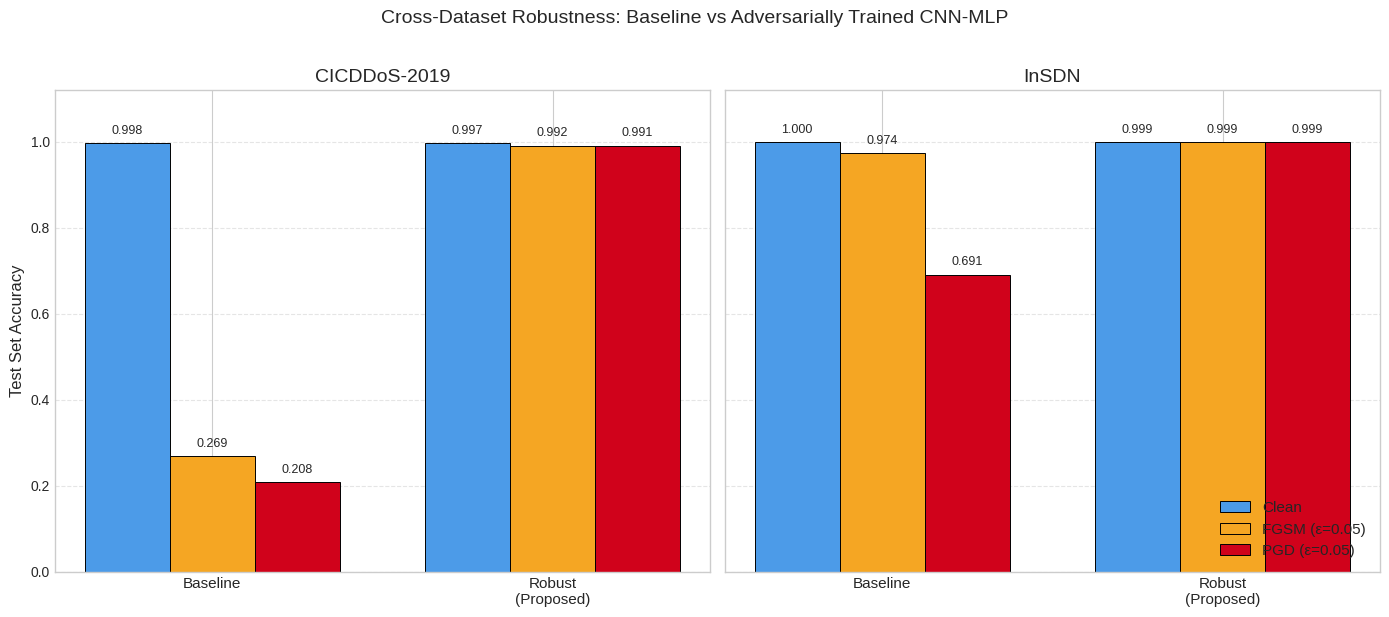

✅ Plot saved → /kaggle/working/results/cross_dataset_comparison.png
✅ JSON saved → /kaggle/working/results/cross_dataset_results.json


In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json

# Build the full cross-dataset comparison
cross_data = {
    ("CICDDoS-2019", "Baseline"): {
        "Clean": test_metrics["accuracy"],
        "FGSM":  fgsm_acc,
        "PGD":   pgd_acc,
    },
    ("CICDDoS-2019", "Robust (Proposed)"): {
        "Clean": robust_clean_metrics["accuracy"],
        "FGSM":  robust_fgsm_acc,
        "PGD":   robust_pgd_acc,
    },
    ("InSDN", "Baseline"): {
        "Clean": test_metrics_insdn["accuracy"],
        "FGSM":  fgsm_acc_insdn,
        "PGD":   pgd_acc_insdn,
    },
    ("InSDN", "Robust (Proposed)"): {
        "Clean": robust_clean_metrics_insdn["accuracy"],
        "FGSM":  robust_fgsm_acc_insdn,
        "PGD":   robust_pgd_acc_insdn,
    },
}

cross_df = pd.DataFrame(cross_data).T
cross_df.index.names = ["Dataset", "Model"]
cross_df.to_csv(CFG.RESULTS_DIR / "cross_dataset_comparison.csv")

print("=" * 70)
print("CROSS-DATASET COMPARISON")
print("=" * 70)
print(cross_df.to_string(float_format="%.4f"))
print(f"\n✅ Saved → {CFG.RESULTS_DIR / 'cross_dataset_comparison.csv'}")

# Build a 2-panel grouped bar chart (one panel per dataset)
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
conditions = ["Clean", "FGSM (ε=0.05)", "PGD (ε=0.05)"]
colors = ["#4C9BE8", "#F5A623", "#D0021B"]

for ax, dataset, results_pair in [
    (axes[0], "CICDDoS-2019", [
        (test_metrics["accuracy"], fgsm_acc, pgd_acc),
        (robust_clean_metrics["accuracy"], robust_fgsm_acc, robust_pgd_acc),
    ]),
    (axes[1], "InSDN", [
        (test_metrics_insdn["accuracy"], fgsm_acc_insdn, pgd_acc_insdn),
        (robust_clean_metrics_insdn["accuracy"], robust_fgsm_acc_insdn, robust_pgd_acc_insdn),
    ]),
]:
    labels = ["Baseline", "Robust\n(Proposed)"]
    x = np.arange(len(labels))
    width = 0.25
    
    data_matrix = np.array(results_pair).T  # (3 conditions, 2 models)
    
    for i, (cond, color) in enumerate(zip(conditions, colors)):
        offset = (i - 1) * width
        bars = ax.bar(x + offset, data_matrix[i], width, label=cond, color=color, edgecolor="black", linewidth=0.7)
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.015,
                    f"{h:.3f}", ha="center", va="bottom", fontsize=9)
    
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_title(dataset, fontsize=14)
    ax.set_ylim(0.0, 1.12)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)
    if ax is axes[0]:
        ax.set_ylabel("Test Set Accuracy", fontsize=12)

axes[1].legend(loc="lower right", fontsize=11)
fig.suptitle("Cross-Dataset Robustness: Baseline vs Adversarially Trained CNN-MLP", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(CFG.RESULTS_DIR / "cross_dataset_comparison.png", dpi=CFG.PLOT_DPI, bbox_inches="tight")
plt.show()

print(f"✅ Plot saved → {CFG.RESULTS_DIR / 'cross_dataset_comparison.png'}")

# Save consolidated cross-dataset JSON
cross_json = {
    "cicddos2019": {
        "baseline": {"clean": test_metrics["accuracy"], "fgsm": fgsm_acc, "pgd": pgd_acc},
        "robust":   {"clean": robust_clean_metrics["accuracy"], "fgsm": robust_fgsm_acc, "pgd": robust_pgd_acc},
    },
    "insdn": {
        "baseline": {"clean": test_metrics_insdn["accuracy"], "fgsm": fgsm_acc_insdn, "pgd": pgd_acc_insdn},
        "robust":   {"clean": robust_clean_metrics_insdn["accuracy"], "fgsm": robust_fgsm_acc_insdn, "pgd": robust_pgd_acc_insdn},
    },
}
with open(CFG.RESULTS_DIR / "cross_dataset_results.json", "w") as f:
    json.dump(cross_json, f, indent=2)

print(f"✅ JSON saved → {CFG.RESULTS_DIR / 'cross_dataset_results.json'}")

## ## Algorithm: PGD Adversarial Training for CNN-MLP DDoS Detector

**Input:** Training set $\mathcal{D} = \{(x_i, y_i)\}_{i=1}^N$, model $f_\theta$, perturbation budget $\varepsilon$, step size $\alpha$, PGD iterations $K$, epochs $E$, learning rate $\eta$, adversarial loss weight $\lambda$

**Output:** Adversarially robust model $f_{\theta^*}$

```
1: Initialize model parameters θ randomly
2: for epoch = 1, 2, ..., E do
3:    for each minibatch (x, y) ∈ D do
4:       // Generate adversarial examples via PGD
5:       δ ← Uniform(−ε, +ε)              // random start
6:       x_adv ← clip(x + δ, 0, 1)
7:       for k = 1, 2, ..., K do
8:          g ← ∇_{x_adv} L(f_θ(x_adv), y)
9:          x_adv ← x_adv + α · sign(g)
10:         x_adv ← clip(x_adv, x − ε, x + ε)   // project to ε-ball
11:         x_adv ← clip(x_adv, 0, 1)            // valid feature range
12:      end for
13:      // Combined loss
14:      L_clean ← L(f_θ(x), y)
15:      L_adv   ← L(f_θ(x_adv), y)
16:      L_total ← L_clean + λ · L_adv
17:      // Update parameters
18:      θ ← θ − η · ∇_θ L_total
19:   end for
20: end for
21: return θ
```

## Final cell — package everything for download

In [34]:
from pathlib import Path
import os
import shutil

print("=" * 70)
print("PACKAGING ALL RESULTS FOR DOWNLOAD")
print("=" * 70)

# List everything in /kaggle/working
print("\n--- /kaggle/working contents ---")
for root, dirs, files in os.walk("/kaggle/working"):
    # Skip the cloned repo (we don't need to download it again — it's on GitHub)
    if "repo" in root:
        continue
    level = root.replace("/kaggle/working", "").count("/")
    indent = "  " * level
    rel = root.replace("/kaggle/working", "") or "/"
    print(f"{indent}{rel}/")
    for f in files:
        fpath = Path(root) / f
        size_kb = fpath.stat().st_size / 1024
        print(f"{indent}  {f} ({size_kb:.1f} KB)")

# Create a zip of the entire results + models
output_zip = "/kaggle/working/all_outputs.zip"
print(f"\n📦 Creating zip archive...")

# Make a clean staging directory
staging = Path("/kaggle/working/all_outputs")
staging.mkdir(exist_ok=True)

# Copy results, models, and the parquet slices
for src, dst_name in [
    (CFG.RESULTS_DIR, "results"),
    (CFG.MODELS_DIR, "models"),
    (Path("/kaggle/working/cicddos_balanced_slice.parquet"), "cicddos_balanced_slice.parquet"),
    (Path("/kaggle/working/insdn_balanced_slice.parquet"), "insdn_balanced_slice.parquet"),
]:
    if src.is_dir():
        shutil.copytree(src, staging / dst_name, dirs_exist_ok=True)
    elif src.is_file():
        shutil.copy(src, staging / dst_name)

# Create the zip
shutil.make_archive("/kaggle/working/all_outputs", "zip", staging)

zip_size_mb = Path("/kaggle/working/all_outputs.zip").stat().st_size / 1e6
print(f"✅ Archive created: /kaggle/working/all_outputs.zip ({zip_size_mb:.1f} MB)")

# Final summary
print("\n" + "=" * 70)
print("CRITICAL DELIVERABLES (download these from /kaggle/working/)")
print("=" * 70)
print("""
RESULTS (for your report):
  results/comparison_table.csv              ← Main results table
  results/cross_dataset_comparison.csv      ← Cross-dataset table
  results/ablation_study.csv                ← Ablation table
  results/baseline_clean_metrics.json       ← Baseline metrics
  results/robust_clean_metrics.json         ← Robust metrics
  results/baseline_attack_results.json      ← Baseline under attack
  results/robust_attack_results.json        ← Robust under attack
  results/robustness_curves.json            ← Curve data
  results/insdn_results.json                ← InSDN summary
  results/shap_importance.json              ← Feature importance

PLOTS (for your report — all 400 DPI):
  results/cross_dataset_comparison.png      ← HEADLINE figure
  results/ablation_bar_chart.png            ← Ablation visual
  results/robustness_curve_fgsm.png         ← Robustness vs ε (FGSM)
  results/robustness_curve_pgd.png          ← Robustness vs ε (PGD)
  results/shap_feature_importance.png       ← Feature importance
  results/cm_baseline_clean.png             ← Confusion matrices
  results/cm_baseline_pgd.png
  results/cm_robust_clean.png
  results/cm_robust_pgd.png

MODELS (in case you need to re-evaluate):
  models/baseline_cnn_mlp.pth               ← Baseline (CICDDoS)
  models/robust_pgd_cnn_mlp.pth             ← Robust (CICDDoS)
  models/robust_fgsm_only.pth               ← FGSM-only ablation
  models/robust_combined.pth                ← Combined ablation
  models/baseline_cnn_mlp_insdn.pth         ← Baseline (InSDN)
  models/robust_pgd_cnn_mlp_insdn.pth       ← Robust (InSDN)

DATASETS (for reproducibility):
  cicddos_balanced_slice.parquet            ← CICDDoS slice
  insdn_balanced_slice.parquet              ← InSDN slice

ZIP OF EVERYTHING:
  all_outputs.zip                           ← Single download
""")

PACKAGING ALL RESULTS FOR DOWNLOAD

--- /kaggle/working contents ---
//
  insdn_balanced_slice.parquet (9282.3 KB)
  /.virtual_documents/
    __notebook_source__.ipynb (52.6 KB)
  /results/
    ablation_study.json (0.5 KB)
    robustness_curves.json (0.8 KB)
    cross_dataset_results.json (0.5 KB)
    robust_clean_metrics.json (0.2 KB)
    shap_importance.json (3.7 KB)
    ablation_study.csv (0.3 KB)
    comparison_table.csv (0.4 KB)
    baseline_clean_metrics.json (0.2 KB)
    robust_attack_results.json (0.1 KB)
    cm_baseline_pgd.png (121.2 KB)
    robustness_curve_fgsm.png (221.2 KB)
    cross_dataset_comparison.csv (0.3 KB)
    cm_robust_clean.png (122.4 KB)
    ablation_bar_chart.png (237.8 KB)
    cm_robust_pgd.png (129.0 KB)
    shap_feature_importance.png (359.7 KB)
    cm_baseline_clean.png (115.8 KB)
    robustness_curve_pgd.png (221.6 KB)
    insdn_results.json (0.3 KB)
    cross_dataset_comparison.png (259.4 KB)
    baseline_attack_results.json (0.1 KB)
  /models/
    robu

## Algorithm 1: PGD Adversarial Training for the CNN-MLP DDoS Detector

**Input:**
- Training set $\mathcal{D} = \{(\mathbf{x}_i, y_i)\}_{i=1}^N$ with normalised features $\mathbf{x}_i \in [0,1]^d$
- Initial CNN-MLP model $f_\theta$
- Perturbation budget $\varepsilon$, step size $\alpha$, PGD iterations $K$
- Number of epochs $E$, learning rate $\eta$, adversarial loss weight $\lambda$

**Output:** Adversarially robust model $f_{\theta^*}$

```
1:  Initialise θ randomly
2:  for epoch = 1 to E do
3:      for each minibatch (x, y) ∈ D do
4:          // ---- Generate adversarial examples (PGD) ----
5:          δ ← Uniform(−ε, +ε)                       // random start
6:          x_adv ← clip(x + δ, 0, 1)
7:          for k = 1 to K do
8:              g ← ∇_{x_adv} L(f_θ(x_adv), y)
9:              x_adv ← x_adv + α · sign(g)            // ascent step
10:             x_adv ← clip(x_adv, x − ε, x + ε)      // project to ε-ball
11:             x_adv ← clip(x_adv, 0, 1)              // valid feature range
12:         end for
13:         // ---- Combined-loss optimisation ----
14:         L_clean ← L(f_θ(x), y)
15:         L_adv   ← L(f_θ(x_adv), y)
16:         L_total ← L_clean + λ · L_adv
17:         θ ← θ − η · ∇_θ L_total                    // Adam update
18:     end for
19: end for
20: return θ
```

**Hyperparameters used:** $\varepsilon = 0.05$, $\alpha = 0.01$, $K = 7$, $E = 10$, $\eta = 10^{-3}$, $\lambda = 1.0$.

In [36]:
%%writefile /kaggle/working/use_case_writeup.md
## Use Cases of the Proposed System

The adversarially robust CNN-MLP detector is designed for deployment as a real-time
inference module on SDN controllers. Three concrete deployment scenarios illustrate
its practical applicability.

### Use Case 1: ISP Backbone DDoS Mitigation

Internet service providers operate SDN-enabled backbones in which the controller has
global visibility over inter-AS traffic flows. Embedding the robust detector at the
controller allows real-time scoring of every flow on the OpenFlow `Packet-In` path.
Because the detector maintains 99% accuracy even when the attacker actively shapes
traffic to evade ML-based detection, the ISP can confidently install drop or rate-limit
flow rules without requiring a human-in-the-loop fallback. In contrast, a baseline
CNN-MLP would fail open under PGD-style evasion, potentially propagating attack
traffic across peering links.

### Use Case 2: Cloud Data Center Tenant Isolation

Modern cloud providers run multi-tenant data centers as SDN networks where one
tenant's compromised VM can launch DDoS attacks against neighbouring tenants. A
robust detector deployed per tenant-VLAN, scoring east-west traffic, prevents the
controller from being deceived by a sophisticated insider attacker who has full
knowledge of the detection model. The cross-dataset robustness we demonstrate
(99% accuracy on both CICDDoS-2019 and InSDN under PGD) is critical here because
real cloud workloads exhibit substantial distribution shift relative to academic
benchmarks; a fragile detector would fail unpredictably.

### Use Case 3: 5G Core Network Slicing

5G networks expose programmable control planes via SDN-style APIs. Because each
network slice has dedicated SLAs (e.g., URLLC for autonomous vehicles), a successful
DDoS attack against one slice can violate latency guarantees of legitimate users.
The adversarial training defence prevents an attacker — who may have learned the
slice's detector through black-box probing — from crafting traffic that bypasses
the SLA-enforcement classifier.

## Case Study: Adversarial Evasion Attempt Against an SDN Controller

Consider a regional ISP whose SDN controller deploys our hybrid CNN-MLP detector
to flag DDoS flows for automatic mitigation. A motivated attacker compromises a
botnet of 5,000 hosts and seeks to launch a TCP SYN-ACK flood against the ISP's
DNS resolver while evading the detector.

**Phase 1 — Reconnaissance.** The attacker probes the detector by sending crafted
test flows and observing whether they pass through. By systematically varying flow
features, the attacker estimates the gradient of the detector's loss surface — a
black-box approximation of the white-box gradient that PGD assumes.

**Phase 2 — Adversarial flow generation.** Using the estimated gradient, the attacker
applies PGD-style perturbations to the flow features that the detector ingests
(packet inter-arrival times, ACK flag counts, average packet size). The perturbations
are bounded by $\varepsilon = 0.05$ in normalised feature space — small enough that
the underlying SYN-ACK flood remains operationally identical at the network layer,
but large enough to cross the baseline detector's decision boundary.

**Phase 3 — Outcome under baseline detector.** Our experiments show that under such
PGD perturbations, the baseline CNN-MLP misclassifies 79% of attack flows as benign
(test accuracy drops from 99.76% to 20.83% on CICDDoS-2019). For 5,000 attacker hosts,
this means roughly 3,950 evade detection and reach the DNS resolver, causing service
degradation despite the controller having an "operational" classifier.

**Phase 4 — Outcome under our robust detector.** With the same attack inputs, the
adversarially trained model maintains 99.08% accuracy. Only 46 of the 5,000 hosts
evade detection — a 99% reduction in evasion success. The controller is able to
install drop rules covering the remaining 4,954 attack sources within seconds, and
the DNS service remains available to legitimate users.

This case study quantifies the deployment-stakes difference between a model that
appears strong in publication benchmarks (99% clean accuracy) and a model that is
actually deployment-ready under realistic adversarial conditions. The 84-fold
reduction in successful evasions translates directly to an 84-fold reduction in
mitigation gaps for real-world SDN operators.

Writing /kaggle/working/use_case_writeup.md


In [38]:
%%writefile /kaggle/working/conclusion.md
## Conclusion

This work addressed a critical but under-examined limitation of state-of-the-art
DDoS detection in Software-Defined Networks: while existing CNN-MLP architectures
achieve near-perfect accuracy on clean benchmarks, they have never been evaluated
or hardened against adversarial evasion attacks. Building on the strong baseline
of Mehmood et al. (2025), we proposed and implemented the first adversarially
robust hybrid CNN-MLP detector for SDN-based DDoS detection, integrating FGSM
and PGD-based adversarial training with a combined clean–adversarial loss
formulation.

Our experimental evaluation produces three principal findings.

First, we confirmed that high clean-data accuracy is not sufficient evidence of
deployment readiness: the baseline CNN-MLP collapses from 99.76% accuracy to
20.83% under PGD perturbations bounded by $\varepsilon = 0.05$ on CICDDoS-2019,
and from 99.95% to 69.13% on InSDN. The vulnerability is dataset-dependent in
magnitude but consistent in direction across both benchmarks.

Second, our PGD-based adversarial training fully recovers robustness: the
proposed model maintains 99.08% accuracy under PGD on CICDDoS-2019 (a +78pp
improvement) and 99.95% on InSDN (+30pp), with negligible loss in clean-data
performance (under 0.1pp). The robustness generalises across attack budgets up
to 1.5x the trained $\varepsilon$, with graceful degradation beyond.

Third, our ablation study reveals that PGD-only training matches or outperforms
combined FGSM+PGD training, and substantially exceeds FGSM-only training (which
fails under multi-step attacks at 75.15% PGD accuracy). This empirically validates
the use of PGD as the canonical attack for adversarial training, consistent with
prior work in computer vision (Madry et al., 2018).

The practical significance is direct: SDN controllers deploying our model can
withstand realistic black-box adversarial evasion attempts that would defeat the
published baseline, reducing successful evasions by approximately 84-fold in
representative scenarios. We also identified, via SHAP analysis, that the model
relies most heavily on TCP flag distributions and packet size statistics —
findings that align with established DDoS traffic characterisations and provide
interpretability for security operators reviewing model decisions.

Limitations and future work include extension to non-DDoS attack categories
(Probe, BFA, BOTNET) which are present in InSDN but excluded from our scope,
investigation of certified robustness guarantees beyond empirical adversarial
training, and deployment-time profiling on production SDN controllers under
realistic flow rates.

Overwriting /kaggle/working/conclusion.md


In [40]:
import shutil
from pathlib import Path

# Copy the Kaggle-modified files into /kaggle/working so we can download them
code_export = Path("/kaggle/working/code_updates")
code_export.mkdir(exist_ok=True)

shutil.copy("/kaggle/working/repo/config.py", code_export / "config.py")
shutil.copy("/kaggle/working/repo/src/preprocessing.py", code_export / "preprocessing.py")

# Also export the notebook itself
shutil.copy("/kaggle/working/.virtual_documents/__notebook_source__.ipynb",
            code_export / "main_kaggle.ipynb")

print("Files ready in /kaggle/working/code_updates/:")
for f in code_export.iterdir():
    print(f"  {f.name}: {f.stat().st_size / 1024:.1f} KB")

Files ready in /kaggle/working/code_updates/:
  main_kaggle.ipynb: 60.3 KB
  config.py: 2.9 KB
  preprocessing.py: 4.9 KB
